In [1]:
import numpy as np
import pandas as pd

from astropy.io import fits
from astropy.table import Table
from astropy.cosmology import w0waCDM
from astropy.cosmology import FlatLambdaCDM
from astropy.cosmology import wCDM

from cosmosis.gaussian_likelihood import GaussianLikelihood
from cosmosis.datablock import names

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches

import statistics as stat
import scipy.stats as stats
from scipy import optimize
from scipy.stats import spearmanr
from scipy.stats import ks_2samp
from scipy.stats import chi2_contingency
from scipy.integrate import quad
from scipy.optimize import curve_fit
from scipy.stats import norm

import nautilus.sampler as ns
from nautilus import Sampler
from nautilus import Prior

import sys
import os

import corner
from corner import quantile

from anesthetic import Samples
from anesthetic import NestedSamples

import camb
from camb import model, initialpower
from camb.baseconfig import CAMBError

import h5py

ns.h5py = h5py

print("Hello world")
c = 299792.458

Hello world


In [2]:
#Check all dependencies
import numpy, scipy, matplotlib, pandas, astropy, sklearn, h5py, camb, corner, anesthetic, nautilus, cosmosis

print("numpy:", numpy.__version__)
print("cosmosis:", cosmosis.__version__)
print("scipy:", scipy.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pandas.__version__)
print("astropy:", astropy.__version__)
print("sklearn:", sklearn.__version__)
print("h5py:", h5py.__version__)
print("camb:", camb.__version__)
print("corner:", corner.__version__)
print("anesthetic:", anesthetic.__version__)
print("nautilus:", nautilus.__version__)

numpy: 2.3.5
cosmosis: 3.25
scipy: 1.16.3
matplotlib: 3.10.8
pandas: 2.3.3
astropy: 7.2.0
sklearn: 1.7.2
h5py: 3.15.1
camb: 1.6.5
corner: 2.2.3
anesthetic: 2.11.0
nautilus: 1.0.5


0.03534109697085073
1687


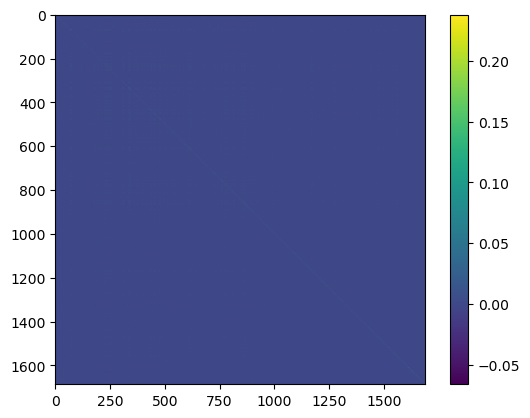

In [3]:
#Defining the likelyhood calculation for SN (including marginalising), BAO and CMB (the same function but repeated for clarity)
def cov_log_likelihood(mu_model, mu, inv_cov):
    delta = np.array([mu_model - mu])
    deltaT = np.transpose(delta)
    chit2 = np.sum(delta @ inv_cov @ deltaT)
    B = np.sum(delta @ inv_cov)
    C = np.sum(inv_cov)
    chi2 = chit2 - (B**2 / C) + np.log(C / (2 * np.pi))
    return -0.5*chi2

def CMB_log_likelihood(CMB_model, CMB, inv_cov):
    delta = np.array([CMB_model - CMB])
    deltaT = np.transpose(delta)
    chi2 = np.sum(delta @ inv_cov @ deltaT)
    return -0.5*chi2

def BAO_log_likelihood(BAO_model, BAO, inv_cov):
    delta = np.array([BAO_model - BAO])
    deltaT = np.transpose(delta)
    chi2 = np.sum(delta @ inv_cov @ deltaT)
    return -0.5*chi2

# Load your data

df = pd.read_csv(
    'DES-Dovekie_HD.csv',
    comment='#',
    sep=r'\s+',
    engine='python'
)

cov_file = "STAT+SYS.npz"

#Selecting only the DES, CFA3, CFA4, CSP and Foundation Sne with zHD>=0.025 and a probability of being 1a over 90%

allowed = [10, 63, 64, 65, 66, 150]

ww = (
    df['IDSURVEY'].isin(allowed) &
    (df['zHD'] >= 0.025) &
    (df['PROBIA_BEAMS'] > 0.9)
)

zCMB = df['zHD'][ww].to_numpy()
zHEL = df['zHEL'][ww].to_numpy()
real_mu = df['MU'][ww].to_numpy()
real_muerr = df['MUERR'][ww].to_numpy()
real_id = df['IDSURVEY'][ww].to_numpy()

# Load covariance
d = np.load(cov_file)
n = d[d.files[0]][0] #size of the square covariance matrix
inv_cov = np.zeros((n, n))
inv_cov[np.triu_indices(n)] = d[d.files[1]] #fills the upper triangle of inv_cov with numbers in npz
i_lower = np.tril_indices(n, -1) #returns the indices of the lower triangle
inv_cov[i_lower] = inv_cov.T[i_lower] #Making inv_cov symmetric
Cov = np.linalg.inv(inv_cov)
Cov = Cov[ww][:, ww] #Including only rows and columns which match criteria laid out above

im = plt.imshow(Cov)
plt.colorbar(im)

#Compute size-normalized diagonal dominance for each row of a covariance matrix C, i.e is the average off diagonal
def row_normalized_dominance(C):
    N = C.shape[0]
    R = np.zeros(N)
    for i in range(N):
        off_diag_sum = np.sum(np.abs(C[i])) - np.abs(C[i, i])
        R[i] = off_diag_sum / ((N - 1) * np.abs(C[i, i]))
    return R

#Test of diagonal dominance:
R = row_normalized_dominance(Cov)
print(np.mean(R))
#Diagonally dominant, 0.035<<1
print(len(real_mu))

Text(0, 0.5, 'Count')

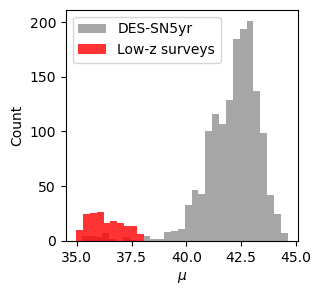

In [4]:
#Bar chart showing distribution of supernovae across the low and high redshift surveys
lowz_ids = {63, 64, 66, 150}

# Boolean masks
lowz_mask = np.isin(real_id, list(lowz_ids))
highz_mask = ~lowz_mask

# Split the data
real_mu_lowz = np.array(real_mu)[lowz_mask]
real_mu_highz = np.array(real_mu)[highz_mask]

plt.figure(figsize=[3,3])

plt.hist(real_mu_highz, bins=30, color='gray', alpha=0.7, label='DES-SN5yr')
plt.hist(real_mu_lowz, bins=10, color='red', alpha=0.8, label='Low-z surveys')

plt.legend()
plt.xlabel("$\mu$")
plt.ylabel("Count")

In [5]:
#Compute CMB covarience matrix with correlations from the literature

corr_CMB1 = [[1, 0.46, -0.66],[0.46, 1, -0.33],[-0.66, -0.33, 1]]
corr_CMB = np.array(corr_CMB1)

CMB_means = np.array([1.7502, 301.471, 0.02236])

sigmas = np.array([0.0046, 0.0895, 0.00015])

cov_CMB = np.diag(sigmas) @ corr_CMB @ np.diag(sigmas)

# Inverse covariance (precision matrix)
inv_CMB = np.linalg.inv(cov_CMB)

print("Covariance matrix:\n", cov_CMB)
print("Inverse covariance matrix:\n", inv_CMB)

#Test of diagonal dominance:
RCMB = row_normalized_dominance(cov_CMB)
print(np.mean(RCMB))
#NOT diagonally dominant, 37.7

Covariance matrix:
 [[ 2.11600e-05  1.89382e-04 -4.55400e-07]
 [ 1.89382e-04  8.01025e-03 -4.43025e-06]
 [-4.55400e-07 -4.43025e-06  2.25000e-08]]
Inverse covariance matrix:
 [[ 9.47889969e+04 -1.32415986e+03  1.65780222e+06]
 [-1.32415986e+03  1.58594485e+02  4.42625856e+03]
 [ 1.65780222e+06  4.42625856e+03  7.88698917e+07]]
37.68928621164279


In [6]:
#BAO COV matrix usinf correlations from literature:

zeff = np.array([0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330])
BAO_real = np.array([7.942, 13.588, 21.863, 17.351, 19.455, 21.576, 17.641, 27.601, 14.176, 30.512, 12.817, 38.988, 8.632])
BAO_errors = [0.075, 0.167, 0.425, 0.177, 0.330, 0.152, 0.193, 0.318, 0.221, 0.760, 0.516, 0.531, 0.101]
BAO_sd = []

for i in range(len(BAO_errors)):
    BAO_sd.append(BAO_errors[i]**2)

BAO_cov = np.diag(BAO_sd)
BAO_corr = [-0.459, -0.404, -0.416, -0.434, -0.500, -0.431]

for i, rho in enumerate(BAO_corr):
    dm_idx = 2*i + 1   # Dm index
    dh_idx = 2*i + 2   # Dh index

    cov = rho * BAO_errors[dm_idx] * BAO_errors[dh_idx]
    BAO_cov[dm_idx, dh_idx] = cov
    BAO_cov[dh_idx, dm_idx] = cov
    
inv_BAO = np.linalg.inv(BAO_cov)

#Test of diagonal dominance:
RBAO = row_normalized_dominance(BAO_cov)
print(np.mean(RBAO))
#Also more or less diagonally dominant, 0.05<<1, although less diagonally dominant than the SN COVMAT

0.04823182757686129


In [7]:
#All likelyhood calculations as laid out in the report
# Supernova likelihood

def likelyhoodSN_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    omb=theta['omb']
    H0=theta['H0']
    
    #Enforcing w0+wa<0, any time this combination occurs, likelyhood returned is -infinity

    if w0 + wa >= 0:
        return -np.inf
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        def MU(z, zHEL):
            result = 5 * np.log10((1 + zHEL)* results.comoving_radial_distance(z)) + 25
            return result

        test_mu = []
        for i in range(1687):
            test_mu.append(MU(zCMB[i],zHEL[i]))

        return cov_log_likelihood(test_mu, real_mu, np.linalg.inv(Cov))

    except CAMBError:
        return -np.inf

#BAO likelyhood:

def likelyhoodBAO_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    if w0 + wa >= 0:
        return -np.inf
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]

        return BAO_log_likelihood(BAO_test, BAO_real, inv_BAO)
    
    except CAMBError:
        return -np.inf

# CMB likelihood

def likelyhoodCMB_w0waCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    wa=theta['wa']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    if w0 + wa >= 0:
        return -np.inf
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        wa=wa,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_means, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
####################################### now for wCDM model
    
def likelyhoodSN_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        def MU(z, zHEL):
            result = 5 * np.log10((1 + zHEL)* results.comoving_radial_distance(z)) + 25
            return result

        test_mu = []
        for i in range(1687):
            test_mu.append(MU(zCMB[i],zHEL[i]))

        return cov_log_likelihood(test_mu, real_mu, np.linalg.inv(Cov))
    
    except CAMBError:
        return -np.inf


def likelyhoodBAO_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]

        return BAO_log_likelihood(BAO_test, BAO_real, inv_BAO)
    
    except CAMBError:
        return -np.inf

def likelyhoodCMB_wCDM(theta):
    Om0 = theta['Om0']
    w0=theta['w0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=w0,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_means, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
####################################### now LCDM
    
def likelyhoodSN_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
        
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        def MU(z, zHEL):
            result = 5 * np.log10((1 + zHEL)* results.comoving_radial_distance(z)) + 25
            return result

        test_mu = []
        for i in range(1687):
            test_mu.append(MU(zCMB[i],zHEL[i]))

        return cov_log_likelihood(test_mu, real_mu, np.linalg.inv(Cov))
    
    except CAMBError:
        return -np.inf
    
def likelyhoodBAO_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        
        r_d = results.get_derived_params()['rdrag']
        H = results.hubble_parameter(zeff)
        Dm = (1 + zeff) * results.angular_diameter_distance(zeff)
        Dm_rd = Dm /r_d
        Dh = c/H
        Dh_rd = Dh/r_d
        
        BAO_test = np.zeros(13)
        
        BAO_test[0] = (zeff[0]*(Dm[0]**2)*Dh[0])**(1/3)/r_d
        BAO_test[1] = Dm_rd[1]
        BAO_test[2] = Dh_rd[1]
        BAO_test[3] = Dm_rd[2]
        BAO_test[4] = Dh_rd[2]
        BAO_test[5] = Dm_rd[3]
        BAO_test[6] = Dh_rd[3]
        BAO_test[7] = Dm_rd[4]
        BAO_test[8] = Dh_rd[4]
        BAO_test[9] = Dm_rd[5]
        BAO_test[10] = Dh_rd[5]
        BAO_test[11] = Dm_rd[6]
        BAO_test[12] = Dh_rd[6]

        return BAO_log_likelihood(BAO_test, BAO_real, inv_BAO)
    
    except CAMBError:
        return -np.inf
    
def likelyhoodCMB_LCDM(theta):
    Om0 = theta['Om0']
    omb=theta['omb']
    H0=theta['H0']
    
    h = H0 / 100.0
    ombh2 = omb * (h**2)
    omch2 = Om0*(h**2) - ombh2
    ommh2 = Om0*(h**2)
    
    try:
        pars = camb.CAMBparams()
        pars.set_cosmology(H0=H0,
            ombh2=ombh2,
            omch2=omch2,
            omk=0)
        
        pars.set_dark_energy(
        w=-1,
        dark_energy_model='ppf'
        )

        results = camb.get_background(pars)
        CMB_test = np.zeros(3)

        g_1 = (0.0783 * (ombh2 ** -0.238))/(1.0 + 39.5 * (ombh2 ** 0.763))
        g_2 = 0.560/(1.0 + 21.1 * (ombh2 ** 1.81))
        zstar = 1048.0 *(1.0 +0.00124 * (ombh2 ** -0.738)) *(1.0 + g_1 * (ommh2 ** g_2))

        #Calculate R
        CMB_test[0] = ((1+zstar) * results.angular_diameter_distance(zstar)*np.sqrt(Om0 * (H0**2)))/c
        #Calculate la
        CMB_test[1] = ((1+zstar) * np.pi * results.angular_diameter_distance(zstar))/results.sound_horizon(zstar)
        #Input ombh2
        CMB_test[2] = ombh2

        return CMB_log_likelihood(CMB_test, CMB_means, inv_CMB)
    
    except CAMBError:
        return -np.inf
    
#####################################################################################################################

#Priors

#w0waCDM
prior_w0waCDM_est = Prior()
prior_w0waCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_w0waCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_w0waCDM_est.add_parameter('wa', dist=(-3,+2))
prior_w0waCDM_est.add_parameter('w0', dist=(-3, -0.4))
prior_w0waCDM_est.add_parameter('H0', dist=(+55, +91))

#wCDM
prior_wCDM_est = Prior()
prior_wCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_wCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_wCDM_est.add_parameter('w0', dist=(-3,-0.4))
prior_wCDM_est.add_parameter('H0', dist=(+55, +91))

#LCDM
prior_LCDM_est = Prior()
prior_LCDM_est.add_parameter('omb', dist=(0.03,0.07))
prior_LCDM_est.add_parameter('Om0', dist=(+0.1, +0.5))
prior_LCDM_est.add_parameter('H0', dist=(+55, +91))

#####################################################################################################################

#Likelihoods for combined probes

def likelyhoodSN_CMB_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodCMB_w0waCDM(theta)

def likelyhoodSN_CMB_BAO_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodCMB_w0waCDM(theta) + likelyhoodBAO_w0waCDM(theta)

def likelyhoodSN_BAO_w0waCDM(theta):
    return likelyhoodSN_w0waCDM(theta) + likelyhoodBAO_w0waCDM(theta)

#######################################

def likelyhoodSN_CMB_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodCMB_wCDM(theta)

def likelyhoodSN_CMB_BAO_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodCMB_wCDM(theta) + likelyhoodBAO_wCDM(theta)

def likelyhoodSN_BAO_wCDM(theta):
    return likelyhoodSN_wCDM(theta) + likelyhoodBAO_wCDM(theta)

#######################################

def likelyhoodSN_CMB_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodCMB_LCDM(theta)

def likelyhoodSN_CMB_BAO_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodCMB_LCDM(theta) + likelyhoodBAO_LCDM(theta)

def likelyhoodSN_BAO_LCDM(theta):
    return likelyhoodSN_LCDM(theta) + likelyhoodBAO_LCDM(theta)

In [8]:


samplerSN_CMB_BAO_w0waCDM_est = Sampler(prior_w0waCDM_est, likelyhoodSN_CMB_BAO_w0waCDM, n_live=1000, filepath = "nautilus_chains/SN_CMB_BAO_w0waCM_est_real.h5")
samplerSN_CMB_BAO_w0waCDM_est.run(verbose=True)

samplerSN_CMB_w0waCDM_est = Sampler(prior_w0waCDM_est, likelyhoodSN_CMB_w0waCDM, n_live=1000, filepath = "nautilus_chains/SN_CMB_w0waCM_est_real.h5")
samplerSN_CMB_w0waCDM_est.run(verbose=True)

samplerSN_BAO_w0waCDM_est = Sampler(prior_w0waCDM_est, likelyhoodSN_BAO_w0waCDM, n_live=1000, filepath = "nautilus_chains/SN_BAO_w0waCM_est_real.h5")
samplerSN_BAO_w0waCDM_est.run(verbose=True)

samplerSN_w0waCDM_est = Sampler(prior_w0waCDM_est, likelyhoodSN_w0waCDM, n_live=1000, filepath = "nautilus_chains/SN_w0waCM_est_real.h5")
samplerSN_w0waCDM_est.run(verbose=True)

#######################################

samplerSN_CMB_BAO_wCDM_est = Sampler(prior_wCDM_est, likelyhoodSN_CMB_BAO_wCDM, n_live=1000, filepath = "nautilus_chains/SN_CMB_BAO_wCD_est_real.h5")
samplerSN_CMB_BAO_wCDM_est.run(verbose=True)

samplerSN_CMB_wCDM_est = Sampler(prior_wCDM_est, likelyhoodSN_CMB_wCDM, n_live=1000, filepath = "nautilus_chains/SN_CMB_wCD_est_real.h5")
samplerSN_CMB_wCDM_est.run(verbose=True)

samplerSN_BAO_wCDM_est = Sampler(prior_wCDM_est, likelyhoodSN_BAO_wCDM, n_live=1000, filepath = "nautilus_chains/SN_BAO_wCD_est_real.h5")
samplerSN_BAO_wCDM_est.run(verbose=True)

samplerSN_wCDM_est = Sampler(prior_wCDM_est, likelyhoodSN_wCDM, n_live=1000, filepath = "nautilus_chains/SN_wCD_est_real.h5")
samplerSN_wCDM_est.run(verbose=True)

#######################################

samplerSN_CMB_BAO_LCDM_est = Sampler(prior_LCDM_est, likelyhoodSN_CMB_BAO_LCDM, n_live=1000, filepath = "nautilus_chains/SN_CMB_BAO_LCD_est_real.h5")
samplerSN_CMB_BAO_LCDM_est.run(verbose=True)

samplerSN_CMB_LCDM_est = Sampler(prior_LCDM_est, likelyhoodSN_CMB_LCDM, n_live=1000, filepath = "nautilus_chains/SN_CMB_LCD_est_real.h5")
samplerSN_CMB_LCDM_est.run(verbose=True)

samplerSN_BAO_LCDM_est = Sampler(prior_LCDM_est, likelyhoodSN_BAO_LCDM, n_live=1000, filepath = "nautilus_chains/SN_BAO_LCD_est_real.h5")
samplerSN_BAO_LCDM_est.run(verbose=True)

samplerSN_LCDM_est = Sampler(prior_LCDM_est, likelyhoodSN_LCDM, n_live=1000, filepath = "nautilus_chains/SN_LCD_est_real.h5")
samplerSN_LCDM_est.run(verbose=True)

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 33     | 1        | 4        | 38900    | N/A    | 10049 | -807.15  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 31     | 1        | 4        | 37000    | N/A    | 10101 | -799.82  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 22     | 1        | 4        | 26000    | N/A    | 10009 | -797.34  
Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 14     | 1        | 4        | 18600    | N/A    | 10068 | -7

np.True_

In [9]:

points_SN_CMB_BAO_w0waCDM, log_w_SN_CMB_BAO_w0waCDM, log_l_SN_CMB_BAO_w0waCDM = samplerSN_CMB_BAO_w0waCDM_est.posterior()
weights = np.exp(log_w_SN_CMB_BAO_w0waCDM)

labels = list(prior_w0waCDM_est.keys)

samples = Samples(points_SN_CMB_BAO_w0waCDM, 
                  weights=weights,
                  columns=labels)
cov = samples.cov()
print(cov)
print(samples.corr())

              omb       Om0        wa        w0        H0
omb  6.950189e-07  0.000004 -0.000008  0.000021 -0.000439
Om0  3.841293e-06  0.000031 -0.000525  0.000203 -0.002926
wa  -8.031693e-06 -0.000525  0.061018 -0.013292  0.022790
w0   2.067039e-05  0.000203 -0.013292  0.003511 -0.016814
H0  -4.389718e-04 -0.002926  0.022790 -0.016814  0.317753
          omb       Om0        wa        w0        H0
omb  1.000000  0.825748 -0.039001  0.418462 -0.934100
Om0  0.825748  1.000000 -0.380859  0.612640 -0.930315
wa  -0.039001 -0.380859  1.000000 -0.908180  0.163668
w0   0.418462  0.612640 -0.908180  1.000000 -0.503420
H0  -0.934100 -0.930315  0.163668 -0.503420  1.000000


Text(0.5, 1.02, 'SN only LCDM')

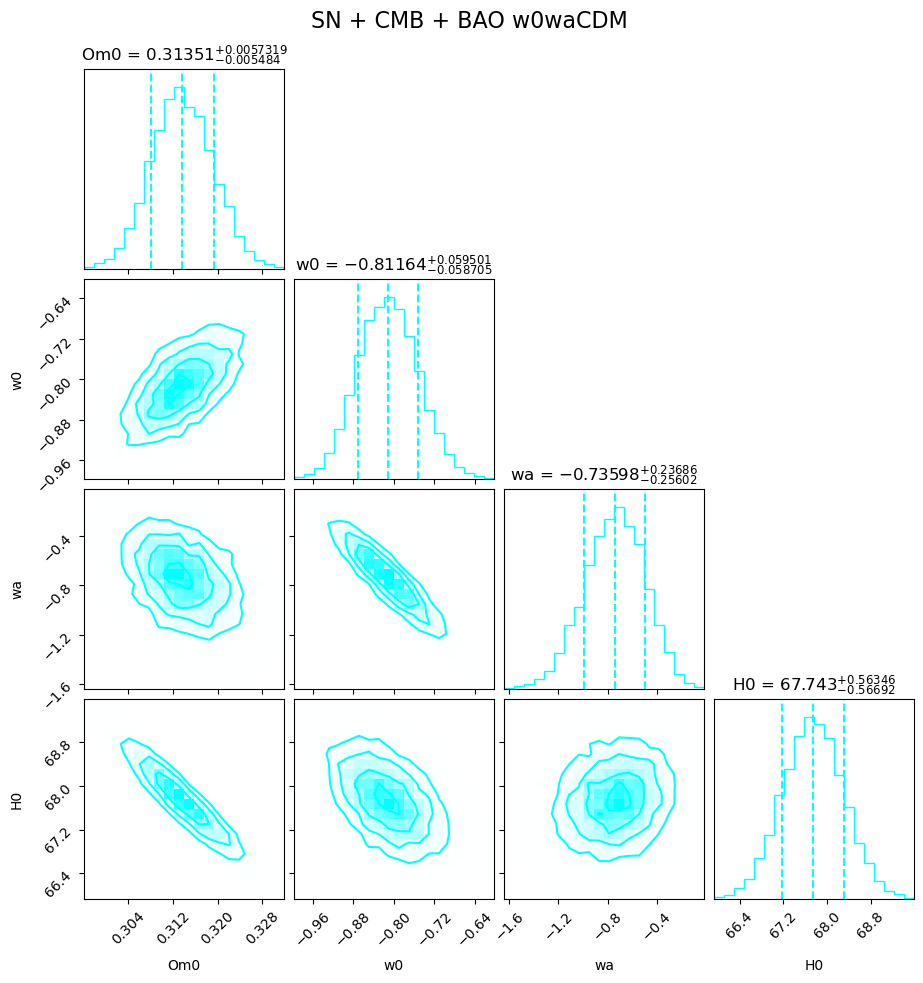

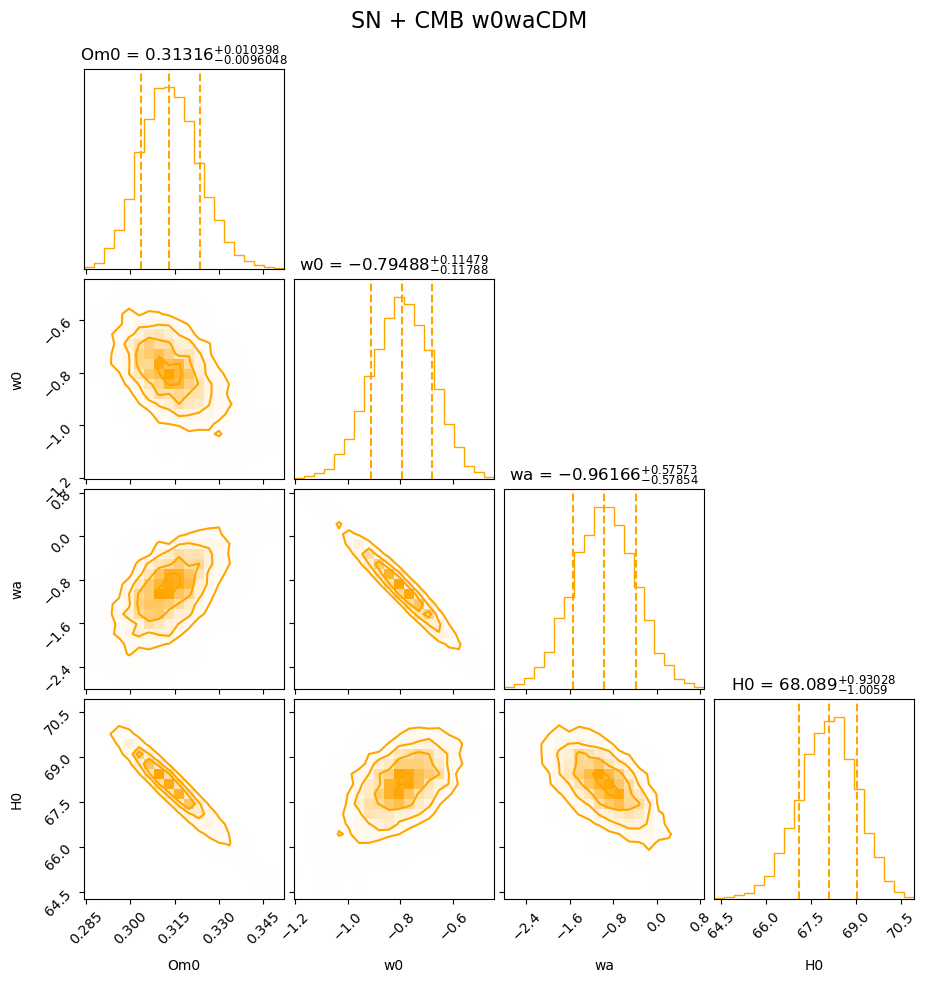

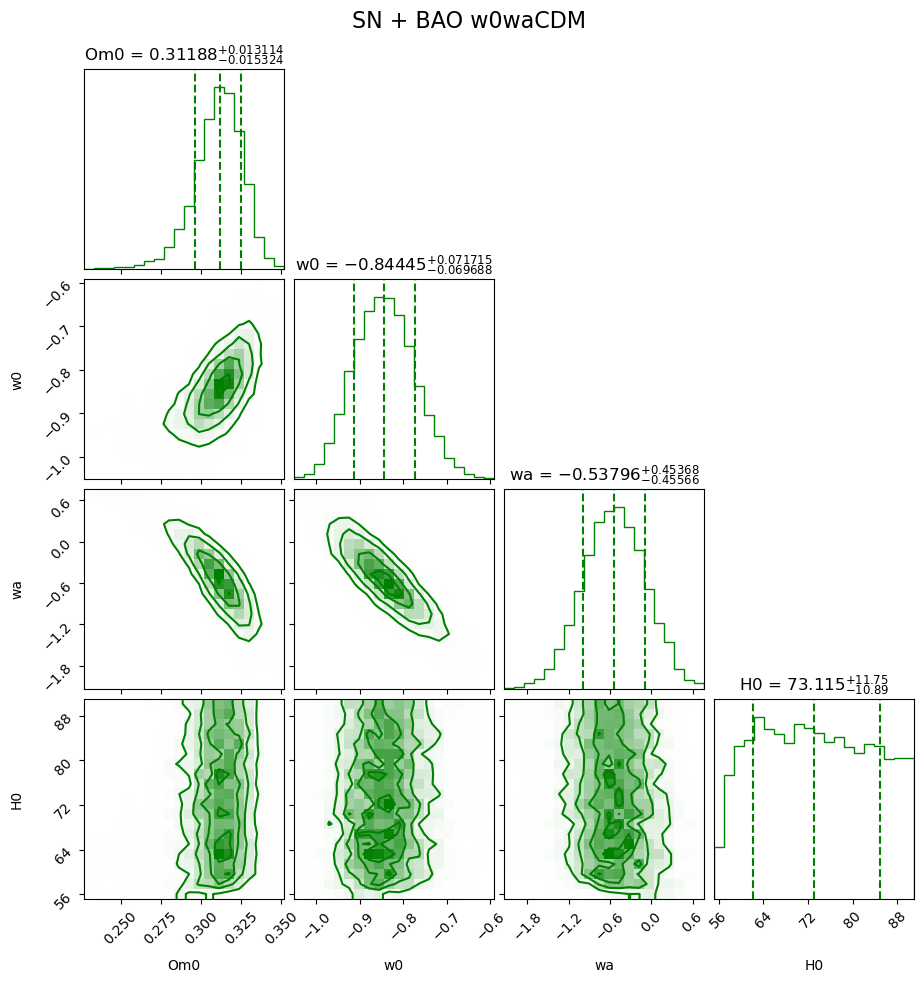

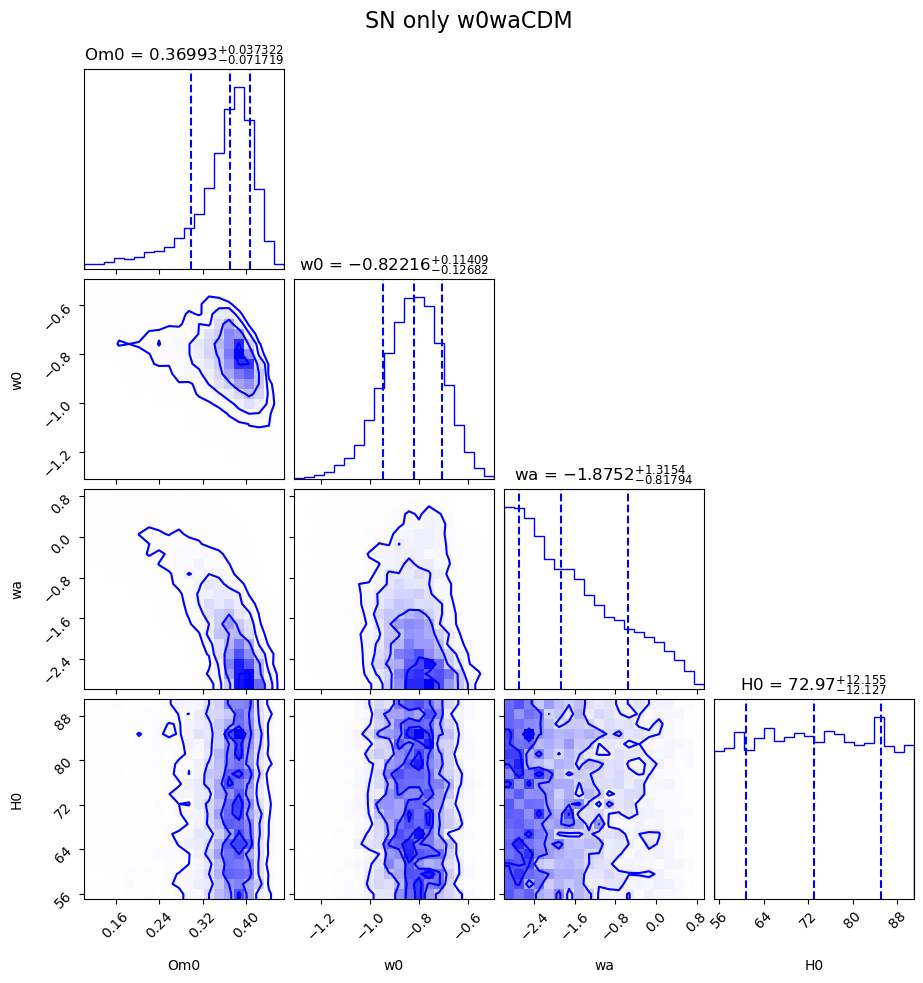

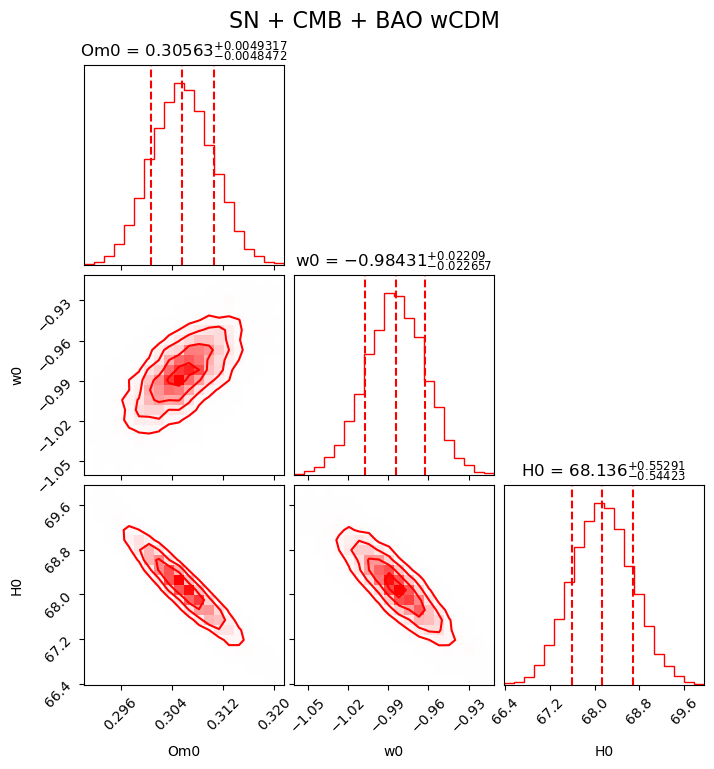

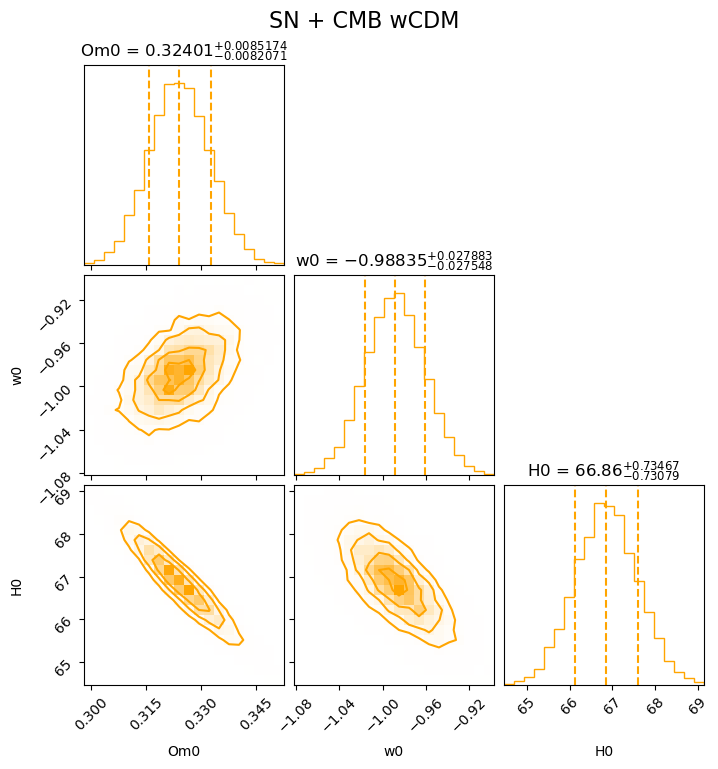

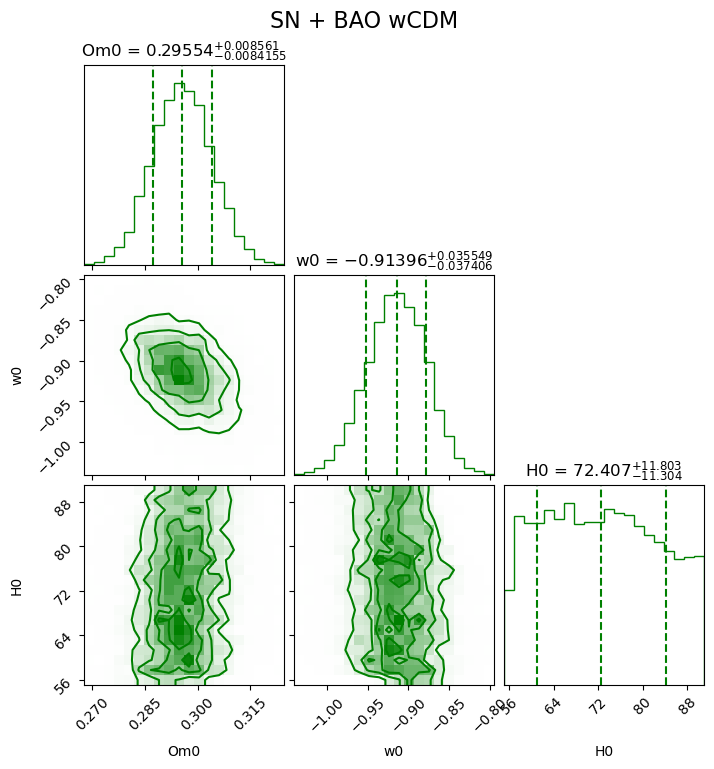

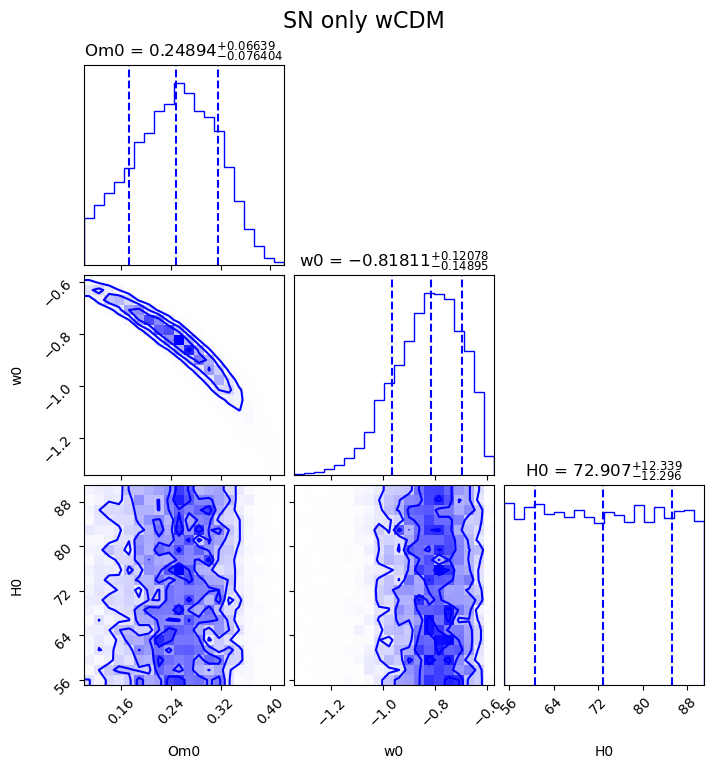

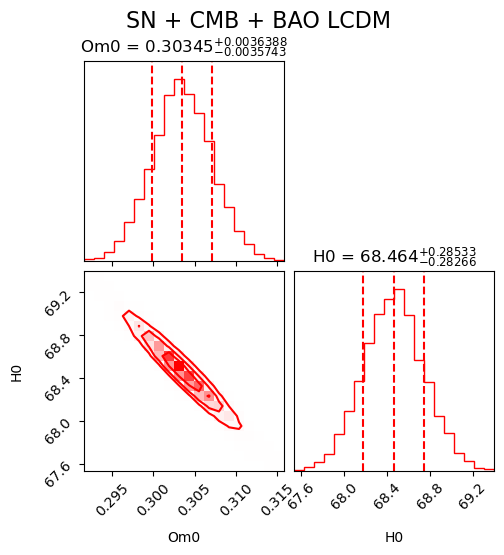

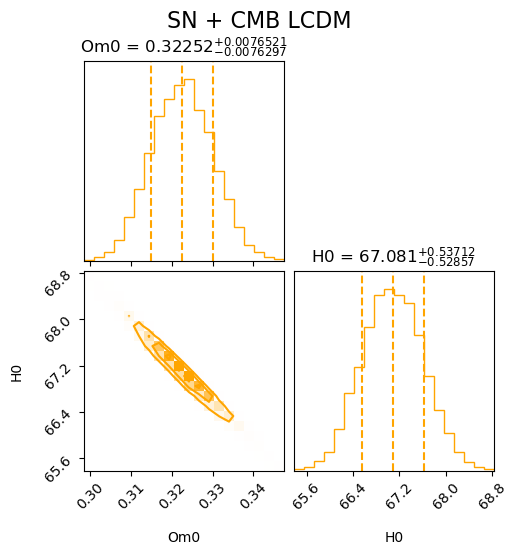

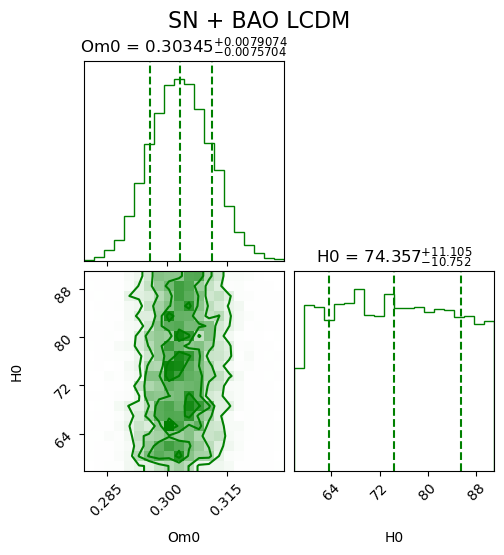

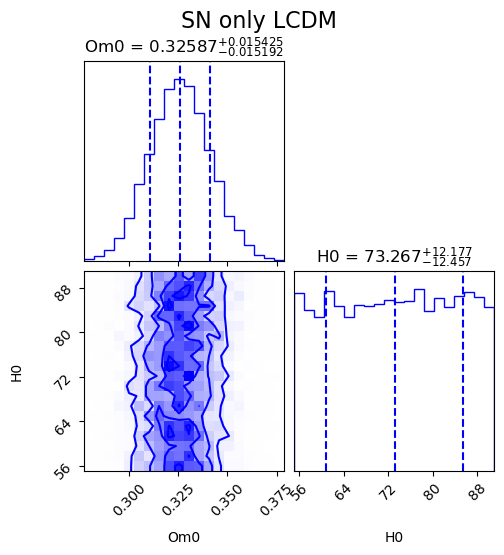

In [10]:
#Corner plotting all results individually:

points_SN_CMB_BAO_w0waCDM, log_w_SN_CMB_BAO_w0waCDM, log_l_SN_CMB_BAO_w0waCDM = samplerSN_CMB_BAO_w0waCDM_est.posterior()

# Parameters wanted
keepSN_CMB_BAO_w0waCDM = ['Om0', 'w0', 'wa', 'H0']

# Original labels in the order of points_2 columns
all_labelsSN_CMB_BAO_w0waCDM = list(prior_w0waCDM_est.keys)

# Indices of the parameters to keep
idxSN_CMB_BAO_w0waCDM = [all_labelsSN_CMB_BAO_w0waCDM.index(p) for p in keepSN_CMB_BAO_w0waCDM]

# Slice samples
points_selSN_CMB_BAO_w0waCDM = points_SN_CMB_BAO_w0waCDM[:, idxSN_CMB_BAO_w0waCDM]

# Corner plot
fig = corner.corner(points_selSN_CMB_BAO_w0waCDM, weights=np.exp(log_w_SN_CMB_BAO_w0waCDM), bins=20, labels=keepSN_CMB_BAO_w0waCDM, color='cyan', plot_datapoints=False, range = np.repeat(0.999, len(keepSN_CMB_BAO_w0waCDM)), quantiles=[0.1585, 0.5, 0.8415], title_fmt=".5g", show_titles=True, title_kwargs={"fontsize": 12})

fig.suptitle("SN + CMB + BAO w0waCDM", fontsize=16, y=1.02)

##############################################

points_SN_CMB_w0waCDM, log_w_SN_CMB_w0waCDM, log_l_SN_CMB_w0waCDM = samplerSN_CMB_w0waCDM_est.posterior()

keepSN_CMB_w0waCDM = ['Om0', 'w0', 'wa', 'H0']

all_labelsSN_CMB_w0waCDM = list(prior_w0waCDM_est.keys)

idxSN_CMB_w0waCDM = [all_labelsSN_CMB_w0waCDM.index(p) for p in keepSN_CMB_w0waCDM]

points_selSN_CMB_w0waCDM = points_SN_CMB_w0waCDM[:, idxSN_CMB_w0waCDM]

fig1 = corner.corner(points_selSN_CMB_w0waCDM, weights=np.exp(log_w_SN_CMB_w0waCDM), bins=20, labels=keepSN_CMB_w0waCDM, color='orange', plot_datapoints=False, range = np.repeat(0.999, len(keepSN_CMB_w0waCDM)), quantiles=[0.1585, 0.5, 0.8415], title_fmt=".5g", show_titles=True, title_kwargs={"fontsize": 12})

fig1.suptitle("SN + CMB w0waCDM", fontsize=16, y=1.02)

##############################################

points_SN_BAO_w0waCDM, log_w_SN_BAO_w0waCDM, log_l_SN_BAO_w0waCDM = samplerSN_BAO_w0waCDM_est.posterior()

keepSN_BAO_w0waCDM = ['Om0', 'w0', 'wa', 'H0']

all_labelsSN_BAO_w0waCDM = list(prior_w0waCDM_est.keys)

idxSN_BAO_w0waCDM = [all_labelsSN_BAO_w0waCDM.index(p) for p in keepSN_BAO_w0waCDM]

points_selSN_BAO_w0waCDM = points_SN_BAO_w0waCDM[:, idxSN_BAO_w0waCDM]

fig2 = corner.corner(points_selSN_BAO_w0waCDM, weights=np.exp(log_w_SN_BAO_w0waCDM), bins=20, labels=keepSN_BAO_w0waCDM, color='green', plot_datapoints=False, range = np.repeat(0.999, len(keepSN_BAO_w0waCDM)), quantiles=[0.1585, 0.5, 0.8415], title_fmt=".5g", show_titles=True, title_kwargs={"fontsize": 12})

fig2.suptitle("SN + BAO w0waCDM", fontsize=16, y=1.02)

##############################################

points_SN_w0waCDM, log_w_SN_w0waCDM, log_l_SN_w0waCDM = samplerSN_w0waCDM_est.posterior()

keepSN_w0waCDM = ['Om0', 'w0', 'wa', 'H0']

all_labelsSN_w0waCDM = list(prior_w0waCDM_est.keys)

idxSN_w0waCDM = [all_labelsSN_w0waCDM.index(p) for p in keepSN_w0waCDM]

points_selSN_w0waCDM = points_SN_w0waCDM[:, idxSN_w0waCDM]

fig3 = corner.corner(points_selSN_w0waCDM, weights=np.exp(log_w_SN_w0waCDM), bins=20, labels=keepSN_w0waCDM, color='blue', plot_datapoints=False, range = np.repeat(0.999, len(keepSN_w0waCDM)), quantiles=[0.1585, 0.5, 0.8415], show_titles=True, title_fmt=".5g", title_kwargs={"fontsize": 12})

fig3.suptitle("SN only w0waCDM", fontsize=16, y=1.02)

##############################################

points_SN_CMB_BAO_wCDM, log_w_SN_CMB_BAO_wCDM, log_l_SN_CMB_BAO_wCDM = samplerSN_CMB_BAO_wCDM_est.posterior()

keepSN_CMB_BAO_wCDM = ['Om0', 'w0', 'H0']

all_labelsSN_CMB_BAO_wCDM = list(prior_wCDM_est.keys)

idxSN_CMB_BAO_wCDM = [all_labelsSN_CMB_BAO_wCDM.index(p) for p in keepSN_CMB_BAO_wCDM]

points_selSN_CMB_BAO_wCDM = points_SN_CMB_BAO_wCDM[:, idxSN_CMB_BAO_wCDM]

fig4 = corner.corner(points_selSN_CMB_BAO_wCDM, weights=np.exp(log_w_SN_CMB_BAO_wCDM), bins=20, labels=keepSN_CMB_BAO_wCDM, color='red', plot_datapoints=False, range = np.repeat(0.999, len(keepSN_CMB_BAO_wCDM)), quantiles=[0.1585, 0.5, 0.8415], title_fmt=".5g", show_titles=True, title_kwargs={"fontsize": 12})

fig4.suptitle("SN + CMB + BAO wCDM", fontsize=16, y=1.02)

##############################################

points_SN_CMB_wCDM, log_w_SN_CMB_wCDM, log_l_SN_CMB_wCDM = samplerSN_CMB_wCDM_est.posterior()

keepSN_CMB_wCDM = ['Om0', 'w0', 'H0']

all_labelsSN_CMB_wCDM = list(prior_wCDM_est.keys)

idxSN_CMB_wCDM = [all_labelsSN_CMB_wCDM.index(p) for p in keepSN_CMB_wCDM]

points_selSN_CMB_wCDM = points_SN_CMB_wCDM[:, idxSN_CMB_wCDM]

fig5 = corner.corner(points_selSN_CMB_wCDM, weights=np.exp(log_w_SN_CMB_wCDM), bins=20, labels=keepSN_CMB_wCDM, color='orange', plot_datapoints=False, range = np.repeat(0.999, len(keepSN_CMB_wCDM)), quantiles=[0.1585, 0.5, 0.8415], title_fmt=".5g", show_titles=True, title_kwargs={"fontsize": 12})

fig5.suptitle("SN + CMB wCDM", fontsize=16, y=1.02)

##############################################

points_SN_BAO_wCDM, log_w_SN_BAO_wCDM, log_l_SN_BAO_wCDM = samplerSN_BAO_wCDM_est.posterior()

keepSN_BAO_wCDM = ['Om0', 'w0', 'H0']

all_labelsSN_BAO_wCDM = list(prior_wCDM_est.keys)

idxSN_BAO_wCDM = [all_labelsSN_BAO_wCDM.index(p) for p in keepSN_BAO_wCDM]

points_selSN_BAO_wCDM = points_SN_BAO_wCDM[:, idxSN_BAO_wCDM]

fig6 = corner.corner(points_selSN_BAO_wCDM, weights=np.exp(log_w_SN_BAO_wCDM), bins=20, labels=keepSN_BAO_wCDM, color='green', plot_datapoints=False, range = np.repeat(0.999, len(keepSN_BAO_wCDM)), quantiles=[0.1585, 0.5, 0.8415], title_fmt=".5g", show_titles=True, title_kwargs={"fontsize": 12})

fig6.suptitle("SN + BAO wCDM", fontsize=16, y=1.02)

##############################################

points_SN_wCDM, log_w_SN_wCDM, log_l_SN_wCDM = samplerSN_wCDM_est.posterior()

keepSN_wCDM = ['Om0', 'w0', 'H0']

all_labelsSN_wCDM = list(prior_wCDM_est.keys)

idxSN_wCDM = [all_labelsSN_wCDM.index(p) for p in keepSN_wCDM]

points_selSN_wCDM = points_SN_wCDM[:, idxSN_wCDM]

fig7 = corner.corner(points_selSN_wCDM, weights=np.exp(log_w_SN_wCDM), bins=20, labels=keepSN_wCDM, color='blue', plot_datapoints=False, range = np.repeat(0.999, len(keepSN_wCDM)), quantiles=[0.1585, 0.5, 0.8415], show_titles=True, title_fmt=".5g", title_kwargs={"fontsize": 12})

fig7.suptitle("SN only wCDM", fontsize=16, y=1.02)

##############################################

points_SN_CMB_BAO_LCDM, log_w_SN_CMB_BAO_LCDM, log_l_SN_CMB_BAO_LCDM = samplerSN_CMB_BAO_LCDM_est.posterior()

keepSN_CMB_BAO_LCDM = ['Om0', 'H0']

all_labelsSN_CMB_BAO_LCDM = list(prior_LCDM_est.keys)

idxSN_CMB_BAO_LCDM = [all_labelsSN_CMB_BAO_LCDM.index(p) for p in keepSN_CMB_BAO_LCDM]

points_selSN_CMB_BAO_LCDM = points_SN_CMB_BAO_LCDM[:, idxSN_CMB_BAO_LCDM]

fig8 = corner.corner(points_selSN_CMB_BAO_LCDM, weights=np.exp(log_w_SN_CMB_BAO_LCDM), bins=20, labels=keepSN_CMB_BAO_LCDM, color='red', plot_datapoints=False, range = np.repeat(0.999, len(keepSN_CMB_BAO_LCDM)), quantiles=[0.1585, 0.5, 0.8415], title_fmt=".5g", show_titles=True, title_kwargs={"fontsize": 12})

fig8.suptitle("SN + CMB + BAO LCDM", fontsize=16, y=1.02)

##############################################

points_SN_CMB_LCDM, log_w_SN_CMB_LCDM, log_l_SN_CMB_LCDM = samplerSN_CMB_LCDM_est.posterior()

keepSN_CMB_LCDM = ['Om0', 'H0']

all_labelsSN_CMB_LCDM = list(prior_LCDM_est.keys)

idxSN_CMB_LCDM = [all_labelsSN_CMB_LCDM.index(p) for p in keepSN_CMB_LCDM]

points_selSN_CMB_LCDM = points_SN_CMB_LCDM[:, idxSN_CMB_LCDM]

fig9 = corner.corner(points_selSN_CMB_LCDM, weights=np.exp(log_w_SN_CMB_LCDM), bins=20, labels=keepSN_CMB_LCDM, color='orange', plot_datapoints=False, range = np.repeat(0.999, len(keepSN_CMB_LCDM)), quantiles=[0.1585, 0.5, 0.8415], title_fmt=".5g", show_titles=True, title_kwargs={"fontsize": 12})

fig9.suptitle("SN + CMB LCDM", fontsize=16, y=1.02)

##############################################

points_SN_BAO_LCDM, log_w_SN_BAO_LCDM, log_l_SN_BAO_LCDM = samplerSN_BAO_LCDM_est.posterior()

keepSN_BAO_LCDM = ['Om0','H0']

all_labelsSN_BAO_LCDM = list(prior_LCDM_est.keys)

idxSN_BAO_LCDM = [all_labelsSN_BAO_LCDM.index(p) for p in keepSN_BAO_LCDM]

points_selSN_BAO_LCDM = points_SN_BAO_LCDM[:, idxSN_BAO_LCDM]

fig10 = corner.corner(points_selSN_BAO_LCDM, weights=np.exp(log_w_SN_BAO_LCDM), bins=20, labels=keepSN_BAO_LCDM, color='green', plot_datapoints=False, range = np.repeat(0.999, len(keepSN_BAO_LCDM)), quantiles=[0.1585, 0.5, 0.8415], title_fmt=".5g", show_titles=True, title_kwargs={"fontsize": 12})

fig10.suptitle("SN + BAO LCDM", fontsize=16, y=1.02)

##############################################

points_SN_LCDM, log_w_SN_LCDM, log_l_SN_LCDM = samplerSN_LCDM_est.posterior()

keepSN_LCDM = ['Om0','H0']

all_labelsSN_LCDM = list(prior_LCDM_est.keys)

idxSN_LCDM = [all_labelsSN_LCDM.index(p) for p in keepSN_LCDM]

points_selSN_LCDM = points_SN_LCDM[:, idxSN_LCDM]

fig11 = corner.corner(points_selSN_LCDM, weights=np.exp(log_w_SN_LCDM), bins=20, labels=keepSN_LCDM, color='blue', plot_datapoints=False, range = np.repeat(0.999, len(keepSN_LCDM)), quantiles=[0.1585, 0.5, 0.8415], title_fmt=".5g", show_titles=True, title_kwargs={"fontsize": 12})

fig11.suptitle("SN only LCDM", fontsize=16, y=1.02)

In [11]:
#All best fit parameters for the CMB+BAO+SN combination for w0waCDM, wCDM and LCDM

points_SN_CMB_BAO_w0waCDM, log_w_SN_CMB_BAO_w0waCDM, log_l_SN_CMB_BAO_w0waCDM = samplerSN_CMB_BAO_w0waCDM_est.posterior()

print("w0waCDM parameters (median ± 1σ):")
for i, param in enumerate(keepSN_CMB_BAO_w0waCDM):
    samples = points_selSN_CMB_BAO_w0waCDM[:, i]
    q16, q50, q84 = quantile(samples, [0.1585, 0.5, 0.8415], weights=np.exp(log_w_SN_CMB_BAO_w0waCDM))
    sigma_minus = q50 - q16
    sigma_plus = q84 - q50
    print(f"{param}: {q50:.4f} (+{sigma_plus:.4f}, -{sigma_minus:.4f})")

##############################################

points_SN_CMB_BAO_wCDM, log_w_SN_CMB_BAO_wCDM, log_l_SN_CMB_BAO_wCDM = samplerSN_CMB_BAO_wCDM_est.posterior()

print("wCDM parameters (median ± 1σ):")
for i, param in enumerate(keepSN_CMB_BAO_wCDM):
    samples = points_selSN_CMB_BAO_wCDM[:, i]
    q16, q50, q84 = quantile(samples, [0.1585, 0.5, 0.8415], weights=np.exp(log_w_SN_CMB_BAO_wCDM))
    sigma_minus = q50 - q16
    sigma_plus = q84 - q50
    print(f"{param}: {q50:.4f} (+{sigma_plus:.4f}, -{sigma_minus:.4f})")

##############################################

points_SN_CMB_BAO_LCDM, log_w_SN_CMB_BAO_LCDM, log_l_SN_CMB_BAO_LCDM = samplerSN_CMB_BAO_LCDM_est.posterior()

print("LCDM parameters (median ± 1σ):")
for i, param in enumerate(keepSN_CMB_BAO_LCDM):
    samples = points_selSN_CMB_BAO_LCDM[:, i]
    q16, q50, q84 = quantile(samples, [0.1585, 0.5, 0.8415], weights=np.exp(log_w_SN_CMB_BAO_LCDM))
    sigma_minus = q50 - q16
    sigma_plus = q84 - q50
    print(f"{param}: {q50:.4f} (+{sigma_plus:.4f}, -{sigma_minus:.4f})")

w0waCDM parameters (median ± 1σ):
Om0: 0.3135 (+0.0057, -0.0055)
w0: -0.8116 (+0.0595, -0.0587)
wa: -0.7360 (+0.2369, -0.2560)
H0: 67.7426 (+0.5635, -0.5669)
wCDM parameters (median ± 1σ):
Om0: 0.3056 (+0.0049, -0.0048)
w0: -0.9843 (+0.0221, -0.0227)
H0: 68.1363 (+0.5529, -0.5442)
LCDM parameters (median ± 1σ):
Om0: 0.3035 (+0.0036, -0.0036)
H0: 68.4641 (+0.2853, -0.2827)


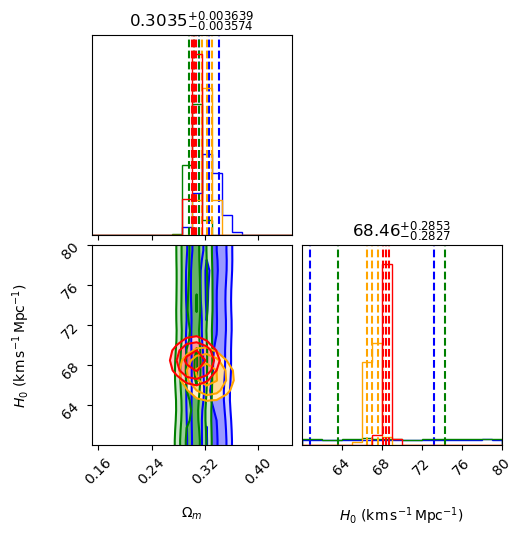

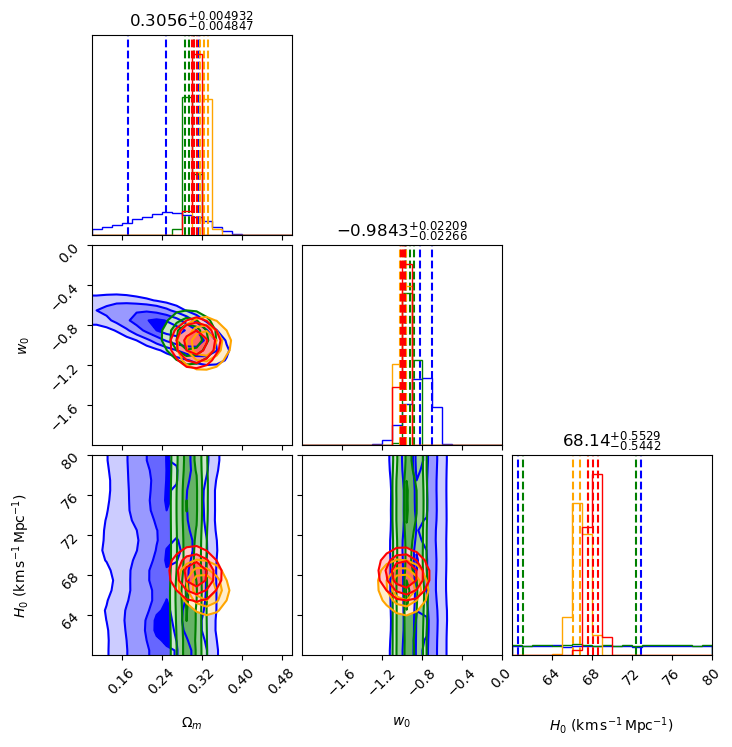

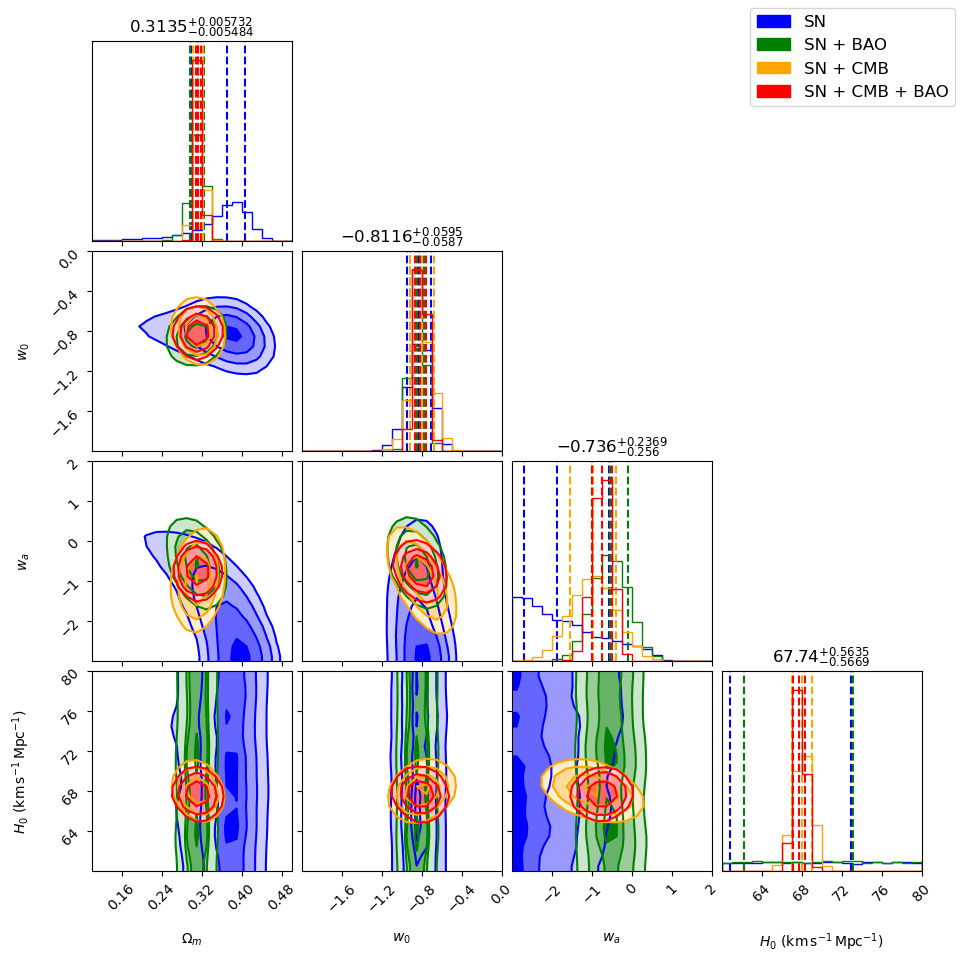

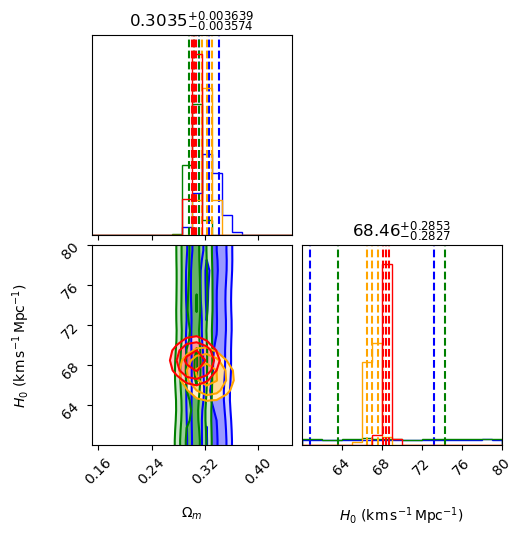

In [12]:
# All probes overlapping graphs

ranges = [
    (0.1, 0.5),     # Om0
    (-2, 0),     # w
    (60, 80),         # H0
]

labels =[
    r"$\Omega_m$",
    r"$w_0$",
    r"$H_0\ \mathrm{(km\,s^{-1}\,Mpc^{-1})}$"
]

fig = corner.corner(
    points_selSN_wCDM,
    weights=np.exp(log_w_SN_wCDM),
    bins=20,
    labels=labels,
    color='blue',
    quantiles=[0.1585, 0.5, 0.8415],
    plot_datapoints=False,
    show_titles=True,
    title_fmt=".4g",
    smooth=1.2,
    range=ranges,
    fill_contours=True,
)


corner.corner(
    points_selSN_BAO_wCDM,
    weights=np.exp(log_w_SN_BAO_wCDM),
    fig=fig,
    color='green',
    quantiles=[0.1585, 0.5, 0.8415],
    plot_datapoints=False,
    show_titles=True,
    title_fmt=".4g",
    smooth=1.2,
    range=ranges,
    fill_contours=True,
)


corner.corner(
    points_selSN_CMB_wCDM,
    weights=np.exp(log_w_SN_CMB_wCDM),
    fig=fig,
    color='orange',
    quantiles=[0.1585, 0.5, 0.8415],
    plot_datapoints=False,
    show_titles=True,
    title_fmt=".4g",
    smooth=1.2,
    range=ranges,
    fill_contours=True,
)


corner.corner(
    points_selSN_CMB_BAO_wCDM,
    weights=np.exp(log_w_SN_CMB_BAO_wCDM),
    fig=fig,
    color='red',
    quantiles=[0.1585, 0.5, 0.8415],
    plot_datapoints=False,
    show_titles=True,
    title_fmt=".4g",
    smooth=1.2,
    range=ranges,
    fill_contours=True,
)

ranges = [
    (0.1, 0.5),     # Om0
    (-2, 0),     # w
    (-3, 2),               # wa
    (60, 80),         # H0
]

labels2 =[
    r"$\Omega_m$",
    r"$w_0$",
    r"$w_a$",
    r"$H_0\ \mathrm{(km\,s^{-1}\,Mpc^{-1})}$"
]

fig2 = corner.corner(
    points_selSN_w0waCDM,
    weights=np.exp(log_w_SN_w0waCDM),
    bins=20,
    labels=labels2,
    color='blue',
    quantiles=[0.1585, 0.5, 0.8415],
    plot_datapoints=False,
    show_titles=True,
    title_fmt=".4g",
    smooth=1.2,
    range=ranges,
    fill_contours=True,
)


corner.corner(
    points_selSN_BAO_w0waCDM,
    weights=np.exp(log_w_SN_BAO_w0waCDM),
    fig=fig2,
    color='green',
    quantiles=[0.1585, 0.5, 0.8415],
    plot_datapoints=False,
    show_titles=True,
    title_fmt=".4g",
    smooth=1.2,
    range=ranges,
    fill_contours=True,
)


corner.corner(
    points_selSN_CMB_w0waCDM,
    weights=np.exp(log_w_SN_CMB_w0waCDM),
    fig=fig2,
    color='orange',
    quantiles=[0.1585, 0.5, 0.8415],
    plot_datapoints=False,
    show_titles=True,
    title_fmt=".4g",
    smooth=1.2,
    range=ranges,
    fill_contours=True,
)


corner.corner(
    points_selSN_CMB_BAO_w0waCDM,
    weights=np.exp(log_w_SN_CMB_BAO_w0waCDM),
    fig=fig2,
    color='red',
    quantiles=[0.1585, 0.5, 0.8415],
    plot_datapoints=False,
    show_titles=True,
    title_fmt=".4g",
    smooth=1.2,
    range=ranges,
    fill_contours=True,
)

blue_patch = mpatches.Patch(color='blue', label='SN')
green_patch = mpatches.Patch(color='green', label='SN + BAO')
orange_patch = mpatches.Patch(color='orange', label='SN + CMB')
red_patch = mpatches.Patch(color='red', label='SN + CMB + BAO')

fig2.legend(
    handles=[blue_patch, green_patch, orange_patch, red_patch],
    loc="upper right",
    fontsize=12
)

ranges = [
    (0.15, 0.45),     # Om0
    (60, 80),         # H0
]

labels3 =[
    r"$\Omega_m$",
    r"$H_0\ \mathrm{(km\,s^{-1}\,Mpc^{-1})}$"
]

fig3 = corner.corner(
    points_selSN_LCDM,
    weights=np.exp(log_w_SN_LCDM),
    bins=20,
    labels=labels3,
    color='blue',
    quantiles=[0.1585, 0.5, 0.8415],
    plot_datapoints=False,
    show_titles=True,
    title_fmt=".4g",
    smooth=1.2,
    range=ranges,
    fill_contours=True,
)


corner.corner(
    points_selSN_BAO_LCDM,
    weights=np.exp(log_w_SN_BAO_LCDM),
    fig=fig3,
    color='green',
    quantiles=[0.1585, 0.5, 0.8415],
    plot_datapoints=False,
    show_titles=True,
    title_fmt=".4g",
    smooth=1.2,
    range=ranges,
    fill_contours=True,
)


corner.corner(
    points_selSN_CMB_LCDM,
    weights=np.exp(log_w_SN_CMB_LCDM),
    fig=fig3,
    color='orange',
    quantiles=[0.1585, 0.5, 0.8415],
    plot_datapoints=False,
    show_titles=True,
    title_fmt=".4g",
    smooth=1.2,
    range=ranges,
    fill_contours=True,
)


corner.corner(
    points_selSN_CMB_BAO_LCDM,
    weights=np.exp(log_w_SN_CMB_BAO_LCDM),
    fig=fig3,
    color='red',
    quantiles=[0.1585, 0.5, 0.8415],
    plot_datapoints=False,
    show_titles=True,
    title_fmt=".4g",
    smooth=1.2,
    range=ranges,
    fill_contours=True,
)
